# Supplementary Figure S43: `s43_gradient_gallery`

**Input-gradient map galleries by seed image.** Site-averaged input-gradient saliency maps for each of the ten encoding models, arranged as ten seed rows by ten model columns, plus a left reference-seed column showing the natural seed images. Each cell in the ten model columns shows a given model's mean gradient map for that seed. These are computed as the $L_2$ magnitude of the model's input-output gradient across color channels, normalized per-map and then averaged over all $25$ site-specific encodings for that model. These maps use a common magma color scale (shared $v_\mathrm{max}$ reflects the $99$th percentile across all models).

Rendered by `figures/supplementary/sup_gradient_gallery.py`; the PNG written below is pixel-identical to the manuscript file `s43_gradient_gallery.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_gradient_gallery import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s43_gradient_gallery.png | sites/model: {'AlexNet_training_seed_01': 25, 'siglip2_vitb16': 25, 'resnet50_clip': 25, 'regnety_640': 25, 'dinov2_vitb14_reg': 25, 'radio_v2.5-b': 25, 'resnet50': 25, 'resnet50_dino': 25, 'resnet50_robust': 25, 'clipag_vitb32': 25}
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s43_gradient_gallery.png


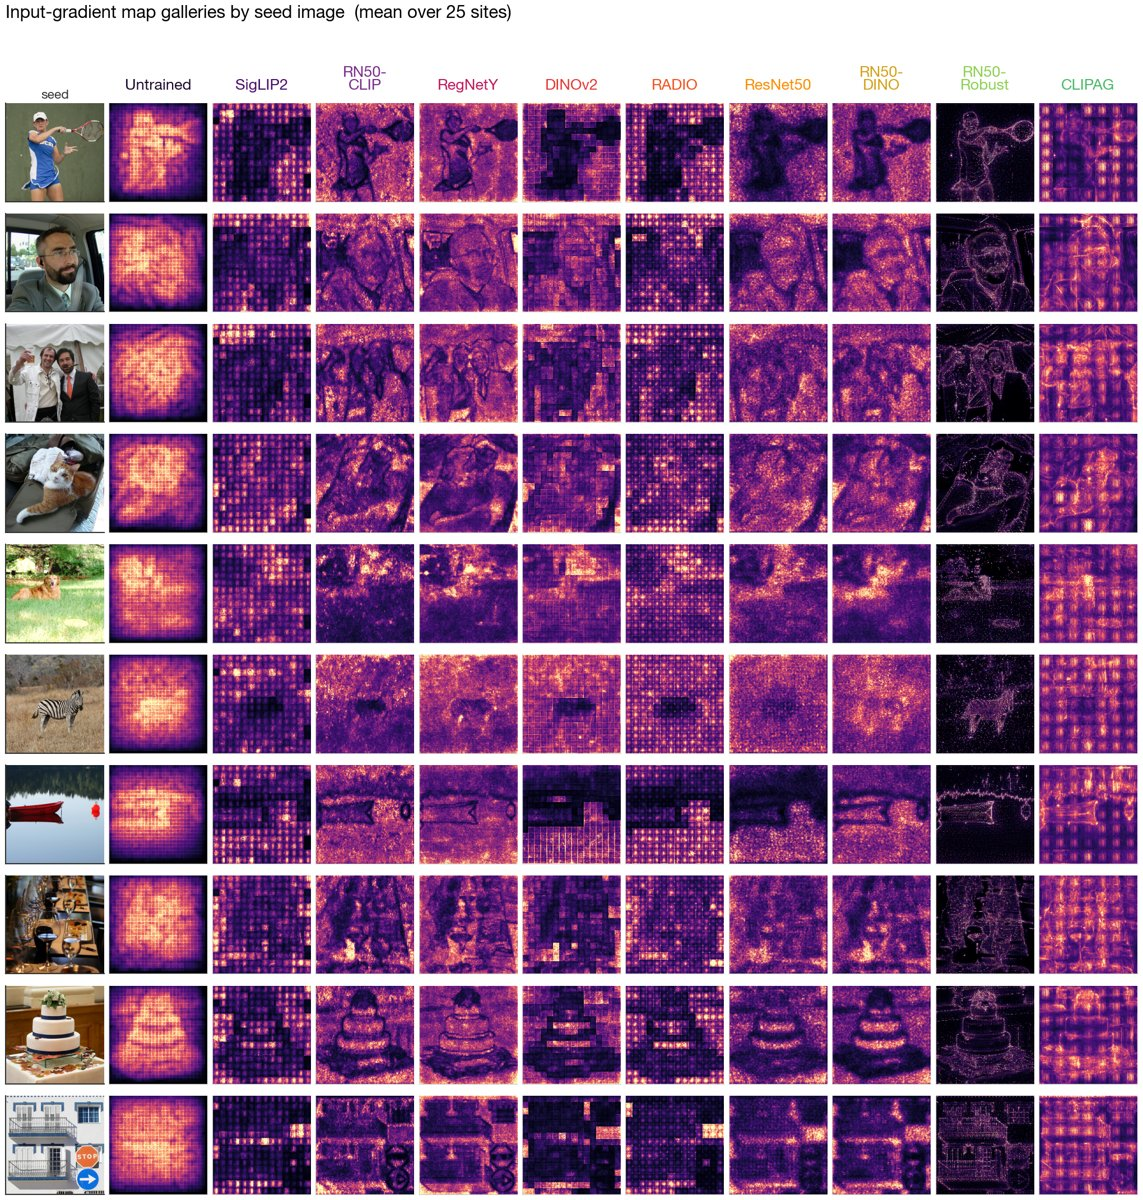

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))